# Create a wavelength lookup table for TBL

In [1]:
import scipp as sc
from ess.reduce import unwrap
from ess.reduce.nexus.types import AnyRun

## Setting up the workflow

In [2]:
source_position = sc.vector([0, 0, 0], unit='m')

wf = unwrap.LookupTableWorkflow()
wf[unwrap.DiskChoppers[AnyRun]] = {}
wf[unwrap.SourcePosition] = source_position
wf[unwrap.NumberOfSimulatedNeutrons] = 200_000  # Increase this number for more reliable results
wf[unwrap.SimulationSeed] = 1234
wf[unwrap.PulseStride] = 1
wf[unwrap.LtotalRange] = sc.scalar(5.0, unit="m"), sc.scalar(35.0, unit="m")
wf[unwrap.DistanceResolution] = sc.scalar(0.1, unit="m")
wf[unwrap.TimeResolution] = sc.scalar(250.0, unit='us')

## Compute the table

In [3]:
table = wf.compute(unwrap.LookupTable)
table.array

<scipp.DataArray>
Dimensions: Sizes[distance:304, event_time_offset:287, ]
Coordinates:
* distance                  float64              [m]  (distance)  [4.8, 4.9, ..., 35, 35.1]
* event_time_offset         float64            [µs]  (event_time_offset)  [0, 249.75, ..., 71178.8, 71428.6]
Data:
                            float64             [Å]  (distance, event_time_offset)  [-nan, 0.211475, ..., 8.07365, 8.30834]  [-nan, 0.000110202, ..., 2.13641, 3.43304]

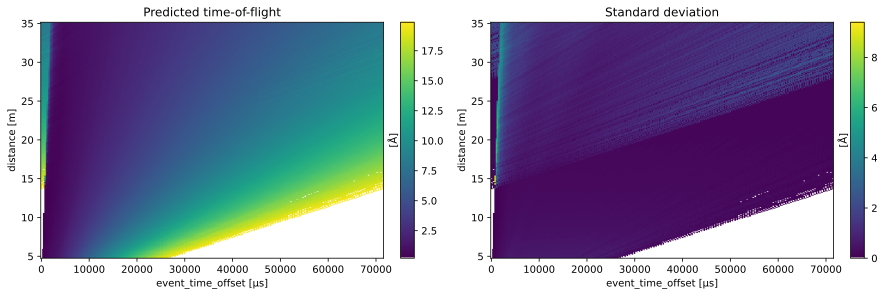

In [4]:
table.plot(title="Predicted time-of-flight") + sc.stddevs(table.array).plot(title="Standard deviation")

## Save to file

In [5]:
# Save chopper metadata
# Write to file
table.save_hdf5('TBL-wavelength-lookup-table-no-choppers-5m-35m.h5')

Writing type '<class 'NoneType'>' to HDF5 not implemented, skipping.
